Sally Linkenauger and Shawn June

# Lab 04: Generating CDFs

Most distributions are discovered by being curious about the world. Someone watches a phenomenon unfold, asks what mechanism could generate it, and then recognizes the mathematical pattern. It's good to remember that math is discovered, not invented.

In each of the following parts, there is a description of a simulation. Each of these simulations generates one of the distributions below, along with its name in `scipy.stats`:

| Distribution | SciPy PDF/PMF | SciPy CDF | Parameters |
|---|---|---|---|
| Beta | `beta.pdf(x, a, b)` | `beta.cdf(x, a, b)` | $(a, b)$ |
| Pareto | `pareto.pdf(x, b, scale=xm)` | `pareto.cdf(x, b, scale=xm)` | shape $b$, minimum $x_m$ |
| Uniform | `uniform.pdf(x, loc=a, scale=b-a)` | `uniform.cdf(x, loc=a, scale=b-a)` | lower $a$, upper $b$ |
| Lognormal | `lognorm.pdf(x, s=sigma, scale=np.exp(mu))` | `lognorm.cdf(x, s=sigma, scale=np.exp(mu))` | $\log X \sim N(\mu, \sigma^2)$ |
| Normal | `norm.pdf(x, loc=mu, scale=sigma)` | `norm.cdf(x, loc=mu, scale=sigma)` | $(\mu, \sigma)$ |
| Exponential | `expon.pdf(x, scale=1/lam)` | `expon.cdf(x, scale=1/lam)` | $\lambda$ |

For parts 1-8 below, program and run the described simulation, plot its distribution using the ECDF, and compare with the distributions above.

**Which simulations generate which CDFs?**

**Pick four simulations to complete. You do not have to do all of them.**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns

# Feel free to add any other imports you need (e.g. statsmodels' ECDF)
np.random.seed(100)  # for reproducibility


## Q1.

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, $\{1/K,\ 2/K,\ ...,\ K/K\}$.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?


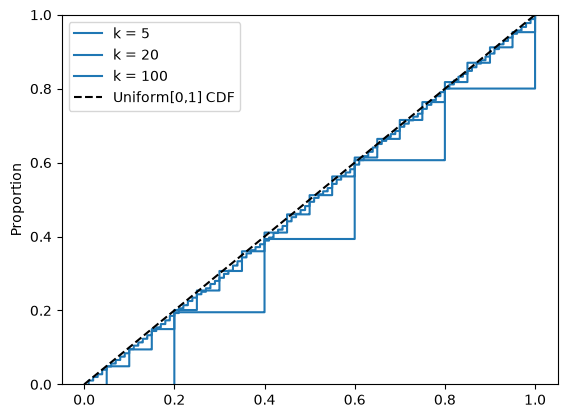

In [2]:
# TODO: Q1 simulation



# 1-3. Build the grid, draw n = 5_000 samples, plot the ECDF for a small K


def gridK (n):
    grid_k = []

    for i in range(1, n+1):
        grid_k.append(i/n)

    return grid_k

samples = np.random.choice(gridK(5), size=5000)  # your sampling step
df_k5 = pd.DataFrame({'draw': samples})

sns.ecdfplot( data= df_k5, label = "k = 5")


# 4. Try increasing K and re-plotting -- what does the ECDF start to look like?


samples = np.random.choice(gridK(20), size=5000)  # your sampling step
df_k20 = pd.DataFrame({'draw': samples})

sns.ecdfplot( data= df_k20, label = "k = 20")



samples = np.random.choice(gridK(100), size=5000)  # your sampling step
df_k100 = pd.DataFrame({'draw': samples})
sns.ecdfplot( data= df_k100, label = "k = 100")

x_grid = np.linspace(0, 1, 200)
plt.plot(x_grid, stats.uniform.cdf(x_grid, loc=0, scale=1), 'k--', label='Uniform[0,1] CDF')
plt.legend()




**Answer:**
What distribution does this approach as you increase $K$?

<font color = "seagreen">
Uniform

The distribution becomes closer and closer to a uniform distribution as you increase k.  Increasing k increases the number of steps that the ECDF takes to traverse from 0 to 1, while simultaneously decreasing the size of the step. The smaller and more numerous the steps, the closer we get to a straight diagonal line, which is the shape of the Uniform [0,1] CDF, F(x) = x. 




## Q2.

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from Uniform $[-\sqrt{3},\ \sqrt{3}]$; these are your data. The choice of $\pm\sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?


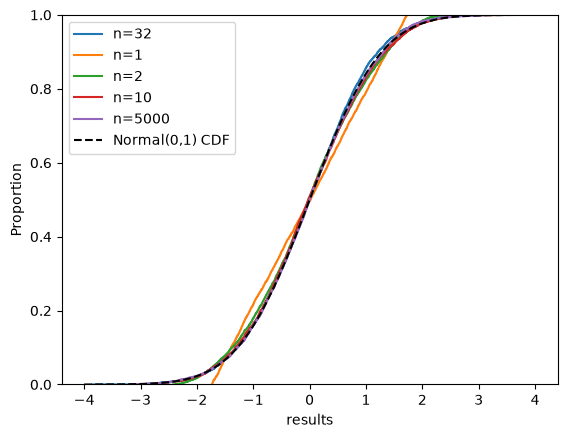

In [3]:
# TODO: Q2 simulation
# 1-2. Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)], compute sqrt(n) * mean

data  = np.random.uniform(low=-np.sqrt(3), high=np.sqrt(3), size=32)

np.mean(data) * np.sqrt(32)


# 3. Repeat b = 5_000 times, plot the ECDF


def q2 (reps, n):

    results = []

    for i in range(reps):
        data  = np.random.uniform(low=-np.sqrt(3), high=np.sqrt(3), size=n)
        results.append(np.mean(data) * np.sqrt(n))
    return pd.DataFrame({"results": results})

results_5000 = q2(5000, 32)


# 4. Try varying n -- how does the ECDF change?

results_5000_1 = q2(5000, 1)

results_5000_2 = q2(5000, 2)

results_5000_10 = q2(5000, 10)


results_5000_5000 = q2(5000, 5000)


sns.ecdfplot(data=results_5000, x='results', label='n=32')
sns.ecdfplot(data=results_5000_1, x='results', label='n=1')
sns.ecdfplot(data=results_5000_2, x='results', label='n=2')
sns.ecdfplot(data=results_5000_10, x='results', label='n=10')
sns.ecdfplot(data=results_5000_5000, x='results', label='n=5000')

x_grid = np.linspace(-4, 4, 200)
plt.plot(x_grid, stats.norm.cdf(x_grid), 'k--', label='Normal(0,1) CDF')
plt.legend()




**Answer:**
What is the distribution of the sample mean?

<font color = "seagreen">
The distribution of the sample mean is a normal distribution. 

With a sample size of 1, you get a straight line, the mean is that value (no averaging) and the sqrt(n) = 1, so the plot is just of the randomly selected 5000 numbers, each having an equal probability regardless of where they are on the distribution. So with one sample, this distribution has a similar shape to Q1.

The normal distribution is produced as a result of drawing means from numerous samples with a variance of 1. As n grows, you are less likely to get large outlier means, because the number of events required for an outlier become less and less likely (coin flips landing all heads 10 times versus 100).  This extremely small likelihood causes the s shaped function.

As you increase the sample size without the standardization (*sqrt(n)), the mean moves from a seemingly normal distribution to a straight vertical line, because the variability in the means across each sample decreases. With a high enough n, every mean that you sample ends up being the almost same, so the normal distribution is compressed into what looks like a straight line. 

 If you standardize the mean based on the sqrt of the sample size, our distribution of the sample mean moves more and more towards the normal distribution with an S-curve that resembles the normal CDF. This standardization means that means from a high n are multiplied by a large number, which magnifies the small differences in the means in samples with high numbers.  For smaller ns, the means are multiplied by smaller numbers, leading to not much of a drastic change in the distribution.

## Q3.

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors.

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
6. How do the results change as you adjust $p$?


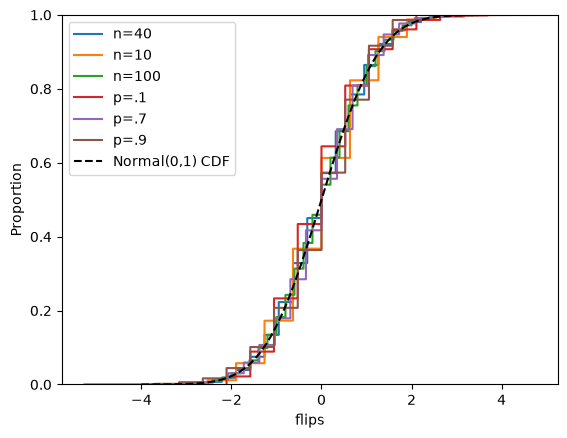

In [18]:
# TODO: Q3 simulation
# 1-3. Flip n = 40 coins with p = 1/2, standardize the head count

heads = np.random.binomial(n=40, p=0.5)
heads
z_heads = (heads - 40 * 0.5) / np.sqrt(40 * 0.5 * (1 - 0.5))


# 4. Repeat b = 5_000 times, plot the ECDF


def coins(n_1, p_1):
    flips = []
    for i in range(5000):
        heads = np.random.binomial(n=n_1, p=p_1)
        heads
        z_heads = (heads - n_1 * p_1) / np.sqrt(n_1 * p_1 * (1 - p_1))
        flips.append(z_heads)
    return pd.DataFrame({"flips": flips})


# 5-6. Try varying n and p -- how does the ECDF change?

flips_40__5 = coins(40, .5)

flips_10_5 = coins(10, .5)

flips_100_5 = coins(100, .5)


flips_40__10 = coins(40, .1)

flips_40_70 = coins(40, .7)

flips_40_90 = coins(40, .9)


sns.ecdfplot(data= flips_40__5, x='flips', label='n=40')
sns.ecdfplot(data= flips_10_5, x='flips', label='n=10')
sns.ecdfplot(data= flips_100_5, x='flips', label='n=100')
sns.ecdfplot(data= flips_40__10, x='flips', label='p=.1')
sns.ecdfplot(data= flips_40_70, x='flips', label='p=.7')
sns.ecdfplot(data= flips_40_90, x='flips', label='p=.9')



x_grid = np.linspace(-4, 4, 200)
plt.plot(x_grid, stats.norm.cdf(x_grid), 'k--', label='Normal(0,1) CDF')
plt.legend()

**Answer:**

<font color = "seagreen">

*As n increases*

Originally a binomial distribution at a small n, this distribution approaches a normal distribution as n increases. As you increase the number of coin flips in each sample, the distribution moves towards normal, because with a larger numbers of flips, we severely decrease the likelihood of extreme means. Here, we are then able to approximate a continuous variable from a discrete measurement (we also standardize this measure as in Q2 to prevent the compression of the mean at high ns).  

As we increase n, the step size of the ECDF decreases, because the steps size is 1/sqrt(np(1-p)). sqrt(np(1-p)) grows as n grows, decreasing the overall term.  Therefore, larger samples more and more approach a continuous distribution due to the smaller intervals in between the possible outcomes of the probabilities.

 
*As p changes*

The step size is also modified as p changes.  Consider 1/sqrt(np(1-p)) again.  sqrt(np(1-p)) increases as p approaches .5 and decreases the further removed it gets from .5. The larger this term gets, the smaller our multiplier 1/sqrt(np(1-p)) becomes and the smaller the step interval.

*Relationship between n and p*

Consider 1/sqrt(np(1-p)) again. Having a high n can reduce the step size even in the event of an extreme p and vice versa (p = .5 in the event you cannot get a higher n).  Hence, these two can play off each other.  This relationship will likely be important when deciding on one's sample size and between different experimental designs. 



## Q4.

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as `dt` goes to zero?
5. How do the results change as you adjust $r$?


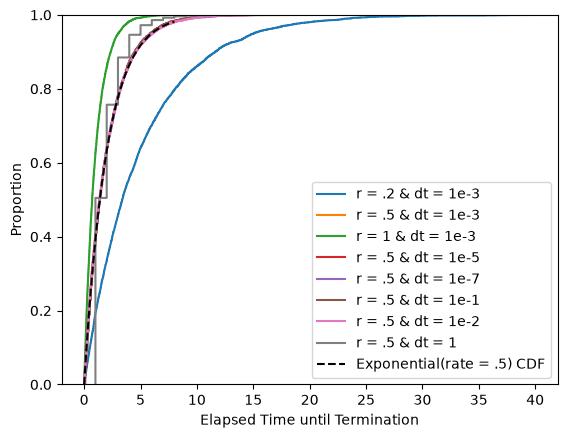

In [5]:
# TODO: Q4 simulation
# 1-3. Simulate the discrete-time termination process, convert to time, plot the ECDF
r= .5
dt = 1e-3
p = r * dt

# r= probability of terminating during interval

def quits (dt, r):
    p = r * dt
    periods = np.random.geometric(p, size= 5000)
    actual_time = periods * dt
    return actual_time
    

sns.ecdfplot(data= quits(1e-3, .2), label='r = .2 & dt = 1e-3')
sns.ecdfplot(data= quits(1e-3, .5), label='r = .5 & dt = 1e-3')
sns.ecdfplot(data= quits(1e-3, 1), label='r = 1 & dt = 1e-3')
sns.ecdfplot(data= quits(1e-5, .5), label='r = .5 & dt = 1e-5')
sns.ecdfplot(data= quits(1e-7, .5), label='r = .5 & dt = 1e-7')
sns.ecdfplot(data= quits(1e-1, .5), label='r = .5 & dt = 1e-1')
sns.ecdfplot(data= quits(1e-2, .5), label='r = .5 & dt = 1e-2')
sns.ecdfplot(data= quits(1, .5), label='r = .5 & dt = 1')

x_grid = np.linspace(0, 8, 200)
plt.plot(x_grid, stats.expon(scale = 1/r).cdf(x_grid), 'k--', label='Exponential(rate = .5) CDF')
plt.xlabel('Elapsed Time until Termination')
plt.legend()

# 4-5. Try varying dt (closer to zero) and r -- how does the ECDF change?


**Answer:**
<font color = "seagreen">

Exponential


*dt approaches 0*

As dt decreases, the ECDF approaches an exponential distribution. Larger dts mean each period covers a larger amount of time, and as a result, our distribution appear chunkier with larger intervals.  Smaller dts are smaller time intervals leading to a smoother exponential curve. The curve become exponential because you are multiplying probabilities of surviving each chunk over numerous chunks with the same probability of surviving.  You are essentially multiplying the same probability to itself each time your move into a new dt.  As you go from one chunk of time to the next, your probability of surviving gets exponentially smaller, because you have to survive one chunk to get to the next. As a result, the chances of surviving are compounded as you move across chunks (dts).  Each time chunk size is the step size. Dt can approach zero, but can never get to 0 because division by zero in the t/dt term in the function is undefined.

*as r changes*

We can consider r as rate at which the process terminates. The r sets the initial slope. The higher the r, the faster the ECDF moves towards termination. The lower the r, the slower the ECDF moves towards termination (see 1 versus .2 rs on the plot).  


## Q5.

We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for understanding **extreme events**: We might be interested in the behavior of the biggest storm or earthquake each year, but be working with a dataset about storms in general over 25 or 50 years.

1. Draw $K = 20$ values from Uniform$[0,\ 1]$.
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat `n` times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to $K$.
6. What distribution(s) does this process generate? How does the distribution depend on the rank?


In [6]:
# TODO: Q5 simulation
# 1-4. Draw K = 20 Uniform[0,1] values, sort, record the largest, repeat n times, plot ECDF


# 5. Repeat for each rank from 1 to K -- how does the ECDF change by rank?


**Answer:**

*(your written answer here)*

## Q6.

Many things in the world grow through a long sequence of small proportional gains and losses: prices bounce around in response to information, tumors grow and shrink, populations expand and contract. When those tiny changes accumulate randomly over time, they produce recognizable patterns.

1. Start at a state of 1.
2. Split a unit of time into $1/\Delta$ small time steps. Start with $\Delta = 1/100$, so $\{0, 1/100, 2/100, ..., 99/100\}$.
3. Each period, the state is multiplied by $u = \exp(\sqrt{\Delta})$ with probability $p = 1/2$ or multiplied by $d = \exp(-\sqrt{\Delta})$ with probability $1-p = 1/2$.
4. Repeat steps 1-3 `B = 1_000` times and record the final position, and plot the ECDF of your sample.
5. What distribution does this approach as $\Delta$ gets close to zero?


In [7]:
# TODO: Q6 simulation
# 1-3. Multiplicative random walk: start at 1, step by u or d each period


# 4. Repeat B = 1_000 times, record final position, plot the ECDF


# 5. Try shrinking Delta -- how does the ECDF change?


**Answer:**

*(your written answer here)*

## Q7.

A surprising regularity appears again and again in human populations: the second-largest city is often roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is called Zipf's law, and it connects the rank of an observation to its size.

1. Suppose there are `K = 100_000` cities, ranked from largest to smallest. Create the ranks $r = \{1, ..., K\}$.
2. Zipf's law says that the size of the city with rank $r$ is proportional to $x_r = (K/r)^s$. Start with $s = 1$.
3. Randomly sample `n=5_000` ranks, with each rank equally likely, and record the corresponding sizes.
4. Plot the ECDF of the simulated sizes.
5. What distribution does this generate as $K$ becomes large?
6. How does the distribution change as you adjust $s$?


In [8]:
# TODO: Q7 simulation
# 1-3. Build the K = 100_000 ranks, compute Zipf sizes x_r = (K/r)^s, sample n = 5_000 ranks


# 4. Plot the ECDF of the simulated sizes


# 5-6. Try varying K and s -- how does the ECDF change?


**Answer:**

*(your written answer here)*

## Q8.

Imagine a toy model of a collection of particles constantly colliding and exchanging energy, while the total amount of energy in the system remains fixed. No particle keeps its energy forever: repeated random exchanges eventually produce a stable distribution even though every individual particle continues to change.

1. Initialize `n = 1_000` particles with energy $E_i = 1$.
2. Randomly choose two particles $i$ and $j$. Add their energies, $E = E_i + E_j$.
3. Draw a uniformly distributed number between 0 and 1, $u$, and redistribute the energy: $E_i = uE$ and $E_j = (1-u)E$.
4. Repeat this random exchange `b=1_000_000` times.
5. Record the final energies of all particles and plot their ECDF.
6. What distribution does this simulation approach as $n$ becomes large?
7. How does the distribution change if you increase or decrease the initial energy for each particle?


In [9]:
# TODO: Q8 simulation
# 1-4. Initialize n = 1_000 particles with E_i = 1, repeatedly pick two at random and redistribute their combined energy


# 5. Plot the ECDF of the final energies


# 6-7. Try varying n and the initial energy -- how does the ECDF change?


**Answer:**

*(your written answer here)*